## Задание 1: Ценовой сегмент телефона

### Импорты и настройки

In [4]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler

from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, classification_report, confusion_matrix, recall_score, fbeta_score
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV

from imblearn.over_sampling import SMOTE

from lightgbm import LGBMClassifier, Dataset
from lightgbm import cv as lgbm_cv

from matplotlib import pyplot as plt

from yellowbrick.model_selection import FeatureImportances

from pprint import pprint

In [5]:
pd.set_option("display.max_columns", None)
%matplotlib inline

RANDOM_STATE = 42

### Загрузка данных

In [3]:
sharing_url = "https://drive.google.com/file/d/1XkKOS6jbke3JYWTj8V_xS46txe820rZ_/view?usp=sharing"
download_url = "https://drive.google.com/uc?id=" + sharing_url.split("/")[-2]

df = pd.read_csv(download_url)

In [4]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1


### EDA

In [ ]:
# Надо будет отскалировать непрерывные фичи
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,9.916500,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,6.064315,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,0.000000,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,5.000000,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,10.000000,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,15.000000,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,20.000000,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [6]:
# Нет null и NaN
# Все данные числовые, кодирование строк в факторы не требуется
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [7]:
# +- прикинуть какие переменные непрерывные, а какие -- категориальные
# (сделаем вид, что описания датасета в задании не существует)
df.nunique()

battery_power    1094
blue                2
clock_speed        26
dual_sim            2
fc                 20
four_g              2
int_memory         63
m_dep              10
mobile_wt         121
n_cores             8
pc                 21
px_height        1137
px_width         1109
ram              1562
sc_h               15
sc_w               19
talk_time          19
three_g             2
touch_screen        2
wifi                2
price_range         4
dtype: int64

In [8]:
# Одинаковое кол-во всех классов. Обойдемся без оверсамплинга.
df["price_range"].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

### Поделим данные и проведем feature-engeneering

In [ ]:
y = df["price_range"]

In [10]:
X = df.drop("price_range", axis=1)

In [11]:
categorical = X.columns[X.nunique() < 3]
continuous  = X.columns[X.nunique() >= 3]

print(categorical, continuous, sep="\n")

Index(['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi'], dtype='object')
Index(['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep',
       'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h',
       'sc_w', 'talk_time'],
      dtype='object')


In [12]:
# Valid не выбираем потому что будем тестировать по K-fold
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True
)

In [13]:
len(X_train), len(y_test)

(1600, 400)

In [14]:
X_train_cont = X_train[continuous]
X_test_cont  = X_test [continuous]

X_train_cat  = X_train[categorical]
X_test_cat   = X_test [categorical]

In [15]:
X_train_cont.head()

,battery_power,clock_speed,fc,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time
968,1923,0.5,7,46,0.5,191,1,10,767,1759,1489,10,9,3
240,633,2.2,0,49,0.1,139,8,1,529,1009,3560,11,1,16
819,1236,0.9,2,57,0.1,188,1,14,517,809,1406,14,12,20
692,781,1.1,2,38,0.4,198,5,7,304,1674,3508,13,8,5
420,1456,0.5,7,7,0.4,105,5,12,823,1104,1587,6,5,20


In [16]:
X_train_cat.head()

,blue,dual_sim,four_g,three_g,touch_screen,wifi
968,0,1,0,1,1,1
240,1,0,1,1,1,1
819,0,1,1,1,0,1
692,0,0,0,0,0,1
420,1,1,0,1,0,1


In [17]:
# Отскалируем непрерывные фичи
scaler= StandardScaler()

pandas_columns = X_train_cont.columns
X_train_cont = scaler.fit_transform(X_train_cont)
X_test_cont = scaler.transform(X_test_cont)

X_train_cont = pd.DataFrame(X_train_cont, columns=pandas_columns)
X_test_cont = pd.DataFrame(X_test_cont, columns=pandas_columns)

In [18]:
X_train_cont.head()

,battery_power,clock_speed,fc,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time
0,1.548360,-1.236230,0.620111,0.754832,-0.008935,1.425710,-1.547446,0.020269,0.275712,1.181997,-0.580476,-0.528061,0.759509,-1.445123
1,-1.379535,0.837112,-0.993561,0.919763,-1.403674,-0.046246,1.510316,-1.476497,-0.258762,-0.556547,1.336453,-0.290196,-1.084869,0.915929
2,-0.010914,-0.748385,-0.532512,1.359577,-1.403674,1.340790,-1.547446,0.685498,-0.285711,-1.020159,-0.657302,0.423400,1.451150,1.642407
3,-1.043621,-0.504462,-0.532512,0.315017,-0.357620,1.623858,0.199847,-0.478653,-0.764042,0.984962,1.288322,0.185535,0.528962,-1.081884
4,0.488416,-1.236230,0.620111,-1.389265,-0.357620,-1.008680,0.199847,0.352883,0.401470,-0.336332,-0.489767,-1.479523,-0.162680,1.642407


In [19]:
# Закодируем категориальные фичи методом One-Hot
encoder = OneHotEncoder(handle_unknown='warn', sparse_output=False)

pandas_columns = X_train_cat.columns

X_train_cat = pd.DataFrame(encoder.fit_transform(X_train_cat))
X_test_cat  = pd.DataFrame(encoder.transform(X_test_cat))

new_columns = encoder.get_feature_names_out(pandas_columns)

X_train_cat.columns = new_columns
X_test_cat.columns = new_columns

In [20]:
X_train_cat.head()

,blue_0,blue_1,dual_sim_0,dual_sim_1,four_g_0,four_g_1,three_g_0,three_g_1,touch_screen_0,touch_screen_1,wifi_0,wifi_1
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
3,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0


In [21]:
# проверка на наличие расхождений
X_train_cont.index.equals(X_train_cat.index), X_test_cont.index.equals(X_test_cat.index)
# вроде все ок

(True, True)

In [22]:
# Финальный X
X_train = pd.concat([X_train_cont, X_train_cat], axis=1)
X_test  = pd.concat([X_test_cont, X_test_cat], axis=1)

In [23]:
X_train.head()

,battery_power,clock_speed,fc,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,blue_0,blue_1,dual_sim_0,dual_sim_1,four_g_0,four_g_1,three_g_0,three_g_1,touch_screen_0,touch_screen_1,wifi_0,wifi_1
0,1.548360,-1.236230,0.620111,0.754832,-0.008935,1.425710,-1.547446,0.020269,0.275712,1.181997,-0.580476,-0.528061,0.759509,-1.445123,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1,-1.379535,0.837112,-0.993561,0.919763,-1.403674,-0.046246,1.510316,-1.476497,-0.258762,-0.556547,1.336453,-0.290196,-1.084869,0.915929,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
2,-0.010914,-0.748385,-0.532512,1.359577,-1.403674,1.340790,-1.547446,0.685498,-0.285711,-1.020159,-0.657302,0.423400,1.451150,1.642407,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
3,-1.043621,-0.504462,-0.532512,0.315017,-0.357620,1.623858,0.199847,-0.478653,-0.764042,0.984962,1.288322,0.185535,0.528962,-1.081884,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,0.488416,-1.236230,0.620111,-1.389265,-0.357620,-1.008680,0.199847,0.352883,0.401470,-0.336332,-0.489767,-1.479523,-0.162680,1.642407,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0


In [24]:
X_train.shape, X_test.shape

((1600, 26), (400, 26))

### Выбор метрик оценки качества

Мы решаем задачу многоклассовой классификации для набора данных со сбалансированными классами. Значит, точно нужно строить матрицу ошибок (хоть это и не метрика, сразу обозначим здесь). Еще это значит, что нам не очень подходит **AUROC** (в лекции называлась AUC) в чистом виде (тк метод рассчитан на бинарную классификацию), но можно рассчитывать его **для каждого класса отдельно** по методике One-vs-Rest и вычислять **микро-усреднение**.

Как говорили выше, классы у нас сбалансированные, поэтому в качестве основной метрики мы возьмем просто **accuracy**. Её же мы будем использовать во время кросс-валидации по k-fold.

Однако мы не знаем, как расперделены классы в тренировочной и тестовой выборках с учетем random shuffle. Именно поэтому возьмем еще и F-меру. Точность и полнота в рамках настоящей задачи одинаково важны, поэтому возьмем **F1** меру, с параметром b(beta)=1 (без предпочтения precision или recall). Она очень удачно есть в `sklearn.metrics.classification_report`, поэтому на **precision** и **recall** тоже сразу посмотрим.

In [ ]:
def custom_classification_report(model: LogisticRegression, y_true):

    # Начал делать это дз почти сразу как только его скинули и только 20.04 заметил, что X тут не идет аргументом
    # Переделывать уже не буду тк многие модели учатся очень долго и в целом это ни на что не должно влиять
    # Но по-хорошему X_test должен заезжать аргументом, конечно.
    preds  = model.predict(X_test)
    probas = model.predict_proba(X_test)

    print("--- Model results ---")

    print("\nAccuracy:")
    print(accuracy_score(y_true, preds))

    print("\nAUROC:")
    print(roc_auc_score(y_true, probas, multi_class="ovr"))

    print("\nConfusion matrix:")
    pprint(confusion_matrix(y_true, preds))

    print("\nClassification report:")
    print(classification_report(y_true, preds))

In [26]:
MAIN_SCORE = "accuracy"

### Построение бейзлайна

In [ ]:
baseline_classifier = LogisticRegression()

In [28]:
kfold = KFold(
    n_splits=5,  # 1600 / 5 = 320
    shuffle=True,
    random_state=RANDOM_STATE
)

In [29]:
cv_scores = cross_val_score(
    LogisticRegression(),
    X_train,
    y_train,
    cv=kfold,
    scoring=MAIN_SCORE
)

In [30]:
cv_scores

array([0.965625, 0.925   , 0.959375, 0.946875, 0.975   ])

In [31]:
baseline_classifier.fit(X_train, y_train)

LogisticRegression()

In [32]:
# Фиксируем околоидеальные результаты
custom_classification_report(baseline_classifier, y_test)

--- Model results ---

Accuracy:
0.975

AUROC:
0.9995844770053641

Confusion matrix:
array([[101,   4,   0,   0],
       [  0,  91,   0,   0],
       [  0,   2,  87,   3],
       [  0,   0,   1, 111]])

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       105
           1       0.94      1.00      0.97        91
           2       0.99      0.95      0.97        92
           3       0.97      0.99      0.98       112

    accuracy                           0.97       400
   macro avg       0.98      0.97      0.97       400
weighted avg       0.98      0.97      0.98       400



/home/smertlove/sandbox/hse/ML_hw/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/smertlove/sandbox/hse/ML_hw/.venv/lib/python3.10/site-packages/yellowbrick/model_selection/importances.py:194: YellowbrickWarning: detected multi-dimensional feature importances but stack=False, using mean to aggregate them.
  warnings.warn(


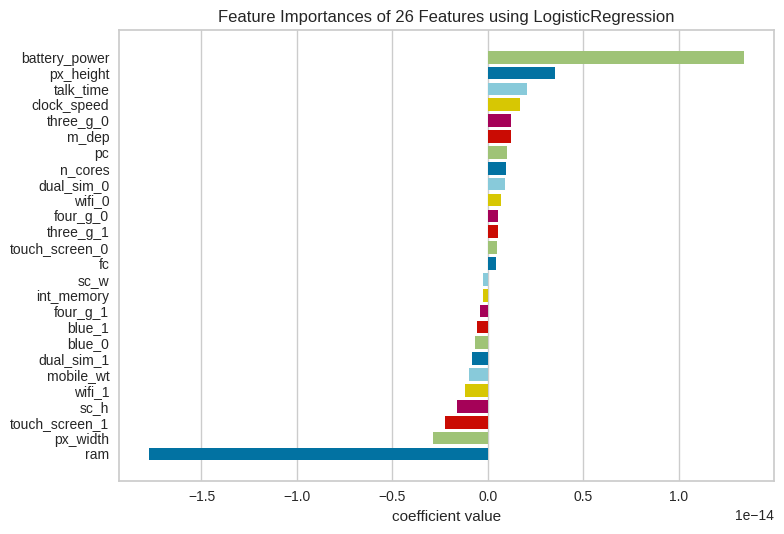

<Axes: title={'center': 'Feature Importances of 26 Features using LogisticRegression'}, xlabel='coefficient value'>

In [33]:
viz = FeatureImportances(baseline_classifier, relative=False)
viz.fit(X_train, y_train)
viz.show()

(возможно, благодаря скалированию) Получились оченть интересные коэффициенты: оказывается, величина оперативной памяти, жирина экрана и наличие сенсорного управления и доступа к wifi сильно негативно влияют на цену телефона, а вот высота экрана наоборот влияет положительно (и отсутствие wifi-адаптера тоже, см середину распределения). Важными оказались фичи, связанные с емкостью батареи и частота такта процессора.

В целом кажется, что модель выучила несуществующие корелляции, просто *очень* удачно.

### Подбор гиперпараметров

In [ ]:
model = LogisticRegression()

param_grid = {
    "penalty"     : ['l1', 'l2', 'elasticnet', None]     ,
    "C"           : [0.001, 0.01, 0.1, 1]                ,
    # "C"           : [c/100 for c in range(1, 21, 1)]     ,
    "solver"      : ["lbfgs", "newton-cg", "sag", "saga"],
    "multi_class" : ["ovr", "multinomial"]               ,
    "class_weight": [None, "balanced"]                   ,
    "max_iter"    : [100, 200]                           ,
    # "max_iter"    : [c for c in range(100, 500, 100)]    ,
    "random_state": [42],
}

grid_search = GridSearchCV(
    model,
    param_grid=param_grid,
    cv=kfold
)

In [35]:
import warnings
warnings.filterwarnings("ignore")

In [36]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1],
                         'class_weight': [None, 'balanced'],
                         'max_iter': [100, 200],
                         'multi_class': ['ovr', 'multinomial'],
                         'penalty': ['l1', 'l2', 'elasticnet', None],
                         'random_state': [42],
                         'solver': ['lbfgs', 'newton-cg', 'sag', 'saga']})

In [37]:
grid_search.best_params_, grid_search.best_score_

({'C': 1,
  'class_weight': 'balanced',
  'max_iter': 200,
  'multi_class': 'multinomial',
  'penalty': 'l1',
  'random_state': 42,
  'solver': 'saga'},
 np.float64(0.968125))

In [38]:
# По-хорошему эти параметры нужно было сунуть в первую сетку.
# Но оно очень долго училось.
param_grid = {
    "penalty"     : ['l1']            ,
    "C"           : [1, 2, 5, 10]     ,
    "solver"      : ["saga"]          ,
    "multi_class" : ["multinomial"]   ,
    "class_weight": ["balanced"],
    "max_iter"    : [200, 300, 400]   ,
    "random_state": [42],
}

grid_search = GridSearchCV(
    model,
    param_grid=param_grid,
    cv=kfold
)

In [39]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(),
             param_grid={'C': [1, 2, 5, 10], 'class_weight': ['balanced'],
                         'max_iter': [200, 300, 400],
                         'multi_class': ['multinomial'], 'penalty': ['l1'],
                         'random_state': [42], 'solver': ['saga']})

In [40]:
grid_search.best_params_, grid_search.best_score_

({'C': 1,
  'class_weight': 'balanced',
  'max_iter': 200,
  'multi_class': 'multinomial',
  'penalty': 'l1',
  'random_state': 42,
  'solver': 'saga'},
 np.float64(0.968125))

In [41]:
best_model = LogisticRegression(**grid_search.best_params_,)
best_model.fit(X_train, y_train)

LogisticRegression(C=1, class_weight='balanced', max_iter=200,
                   multi_class='multinomial', penalty='l1', random_state=42,
                   solver='saga')

In [42]:
custom_classification_report(best_model, y_test)

--- Model results ---

Accuracy:
0.98

AUROC:
0.9998123338391681

Confusion matrix:
array([[102,   3,   0,   0],
       [  0,  91,   0,   0],
       [  0,   2,  88,   2],
       [  0,   0,   1, 111]])

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       105
           1       0.95      1.00      0.97        91
           2       0.99      0.96      0.97        92
           3       0.98      0.99      0.99       112

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



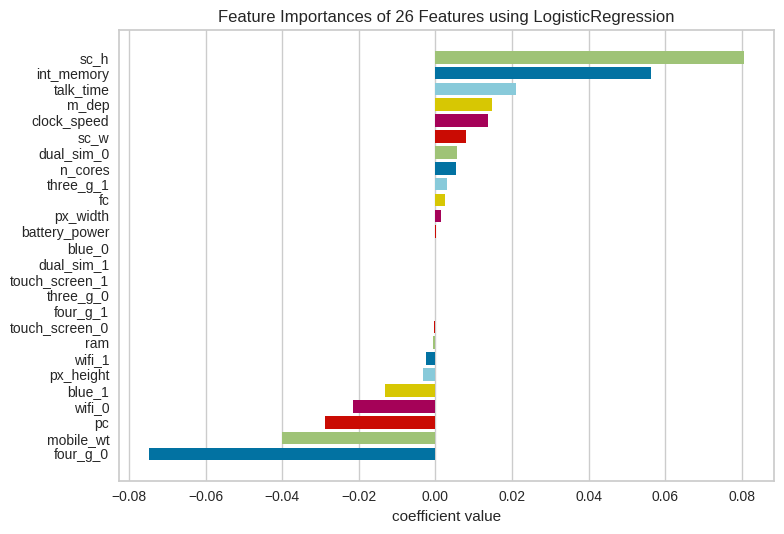

<Axes: title={'center': 'Feature Importances of 26 Features using LogisticRegression'}, xlabel='coefficient value'>

In [43]:
viz = FeatureImportances(best_model, relative=False)
viz.fit(X_train, y_train)
viz.show()

Вот эти веса уже сильно больше похожи на реальность. Высота экрана, количество памяти, емкость батареи в режиме разговора(?), частота такта процессора, ширина экрана, внезапно отсутствие второй симкарты(??), количество ядер и наличие 3g положительно влияют на цену. Отсутствие 4g, вес телефона, отсутствие wifi адаптера влияют отрицательно. Из необычного все еще  наличие bluetooth, wifi и казалось бы положительные характеристики камеры влияют на цену отрицательно.

### Baseline LGBM

In [44]:
cross_val_score(
    LGBMClassifier(),
    X_train,
    y_train,
    cv=kfold,
    scoring=MAIN_SCORE
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000172 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1375
[LightGBM] [Info] Number of data points in the train set: 1280, number of used features: 26
[LightGBM] [Info] Start training from score -1.414822
[LightGBM] [Info] Start training from score -1.337504
[LightGBM] [Info] Start training from score -1.358558
[LightGBM] [Info] Start training from score -1.437588
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000180 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1375
[LightGBM] [Info] Number of data points in the train set: 1280, number of used features: 26
[LightGBM] [Info] Start training from score -1.392564
[Lig

array([0.909375, 0.884375, 0.9125  , 0.921875, 0.90625 ])

In [45]:
lgbm_baseline = LGBMClassifier()

In [46]:
lgbm_baseline.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1376
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 26
[LightGBM] [Info] Start training from score -1.398873
[LightGBM] [Info] Start training from score -1.364044
[LightGBM] [Info] Start training from score -1.366492
[LightGBM] [Info] Start training from score -1.416754
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier()

In [47]:
custom_classification_report(lgbm_baseline, y_test)

--- Model results ---

Accuracy:
0.9

AUROC:
0.9911081309313425

Confusion matrix:
array([[100,   5,   0,   0],
       [  4,  85,   2,   0],
       [  0,  10,  75,   7],
       [  0,   0,  12, 100]])

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       105
           1       0.85      0.93      0.89        91
           2       0.84      0.82      0.83        92
           3       0.93      0.89      0.91       112

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



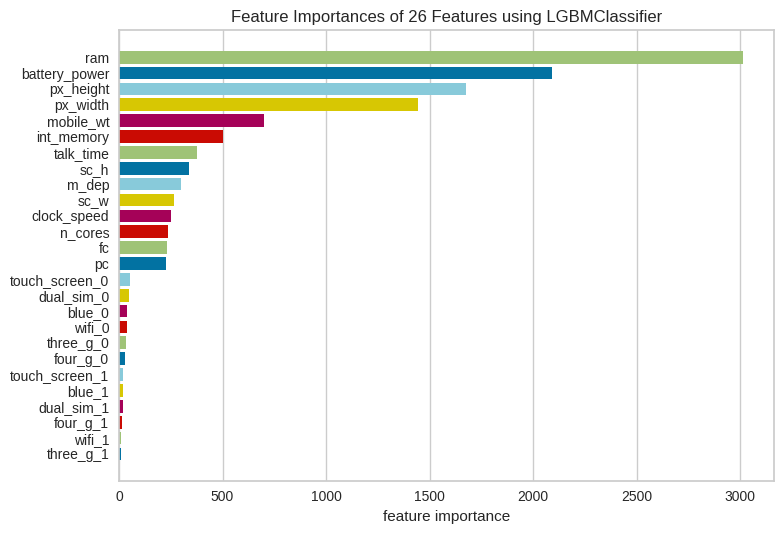

<Axes: title={'center': 'Feature Importances of 26 Features using LGBMClassifier'}, xlabel='feature importance'>

In [48]:
viz = FeatureImportances(lgbm_baseline, relative=False)
viz.fit(X_train, y_train)
viz.show()

Очень интересно категориальные признаки почти не влияют на предсказания. При чем наличие фич влияет еще меньше, чем их отсутствие.

### Подбор гиперпараметров

Многое закомментировано ротому что даже эта сетка бежит час.

In [ ]:
param_grid = {
    # Этот параметр указывает модель, которая будет буститься.
    # По заданию у нас бустинг над решающими деревьями, поэтому значение тут только одно.
    "boosting_type": ['gbdt',],

    # Максимальное количество листьев в дереве.
    # Чем меньше, тем ниже риск переобучения.
    "num_leaves": [31] + [i for i in range(3, 33, 10)],

    # Максимальная глубина ветвления.
    # Чем меньше, тем ниже риск переобучения.
    "max_depth": [-1] + [i for i in range(1, 101, 20)],

    # Альфа-коэффициент
    # Замедляет обучение, улучшает сходимость
    # "learning_rate": [1, 0.1, 0.01],

    # Кол-во моделей в ансамбле
    "n_estimators": [n for n in range(10, 210, 10)],

    # Цель обучения
    "objective": ["multiclass"],

    # Баланс классов в выборке
    "class_weight": ["balanced"],

    # Минимальное уменьшение лосса, необходимое для дальнейшего деления дерева
    # "min_split_gain": [0., 0.000001],

    # Минимальная сумма веса экземпляров, необходимая для листа.
    "min_child_weight": [1e-3, 1e-2, 1e-1],

    # Минимальное количество детей в листе, необходимое для дальнейшего деления дерева
    # "min_child_samples": [5, 10, 20, 30, 40],

    # Доля тренировочных данных, на которых обучается каждое дерево.
    # "subsample": [1, 0.5, 0.2],

    # Частота доли
    # "subsample_freq": [0, 0.2],

    # Доля фич, на которых учится каждое дерево
    # "colsample_bytree" : [1, 0.5, 0.2],

    # Параметры регуляризации
    "reg_alpha" : [0.],
    "reg_lambda" :[0.],

    # Тут понятно
    "random_state": [42],

    # Кол-во параллельных потоков для обучения ансамбля
    # Тут используем все ядра
    "n_jobs": [-1],

    # МОЛЧА
    "verbose": [-1]
}

In [ ]:
# Я сожалею о своем решении использовать это и в следующий раз попробую lgbm.cv
grid_search = GridSearchCV(
    LGBMClassifier(),
    param_grid=param_grid,
    cv=kfold,
    verbose= False
)

In [51]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LGBMClassifier(),
             param_grid={'boosting_type': ['gbdt'],
                         'class_weight': ['balanced'],
                         'max_depth': [-1, 1, 21, 41, 61, 81],
                         'min_child_weight': [0.001, 0.01, 0.1],
                         'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90,
                                          100, 110, 120, 130, 140, 150, 160,
                                          170, 180, 190, 200],
                         'n_jobs': [-1], 'num_leaves': [31, 3, 13, 23],
                         'objective': ['multiclass'], 'random_state': [42],
                         'reg_alpha': [0.0], 'reg_lambda': [0.0],
                         'verbose': [-1]},
             verbose=False)

In [52]:
grid_search.best_params_, grid_search.best_score_

({'boosting_type': 'gbdt',
  'class_weight': 'balanced',
  'max_depth': -1,
  'min_child_weight': 0.001,
  'n_estimators': 200,
  'n_jobs': -1,
  'num_leaves': 3,
  'objective': 'multiclass',
  'random_state': 42,
  'reg_alpha': 0.0,
  'reg_lambda': 0.0,
  'verbose': -1},
 np.float64(0.913125))

In [54]:
best_lgbm = LGBMClassifier(**grid_search.best_params_)

In [55]:
best_lgbm.fit(X_train, y_train)

LGBMClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
               num_leaves=3, objective='multiclass', random_state=42,
               verbose=-1)

In [56]:
custom_classification_report(best_lgbm, y_test)

--- Model results ---

Accuracy:
0.9175

AUROC:
0.9922548366795886

Confusion matrix:
array([[102,   3,   0,   0],
       [  5,  81,   5,   0],
       [  0,   5,  81,   6],
       [  0,   0,   9, 103]])

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       105
           1       0.91      0.89      0.90        91
           2       0.85      0.88      0.87        92
           3       0.94      0.92      0.93       112

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400



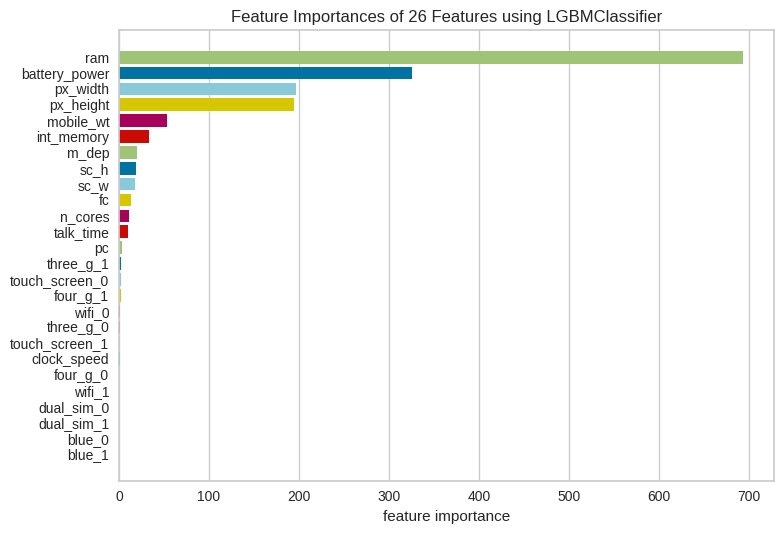

<Axes: title={'center': 'Feature Importances of 26 Features using LGBMClassifier'}, xlabel='feature importance'>

In [57]:
viz = FeatureImportances(best_lgbm, relative=False)
viz.fit(X_train, y_train)
viz.show()

### TODO: описание фич и моделей

## Задание 2: Возгорание

In [6]:
sharing_url = "https://drive.google.com/file/d/1TJI9IVaZQtaTJUezLrC3WaQ-eEC40AGG/view?usp=sharing"
download_url = "https://drive.google.com/uc?id=" + sharing_url.split("/")[-2]

df = pd.read_csv(download_url)

In [7]:
df.head()

,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,0,1654733331,20.000,57.36,0,400,12306,18520,939.735,0.0,0.0,0.0,0.0,0.0,0,0
1,1,1654733332,20.015,56.67,0,400,12345,18651,939.744,0.0,0.0,0.0,0.0,0.0,1,0
2,2,1654733333,20.029,55.96,0,400,12374,18764,939.738,0.0,0.0,0.0,0.0,0.0,2,0
3,3,1654733334,20.044,55.28,0,400,12390,18849,939.736,0.0,0.0,0.0,0.0,0.0,3,0
4,4,1654733335,20.059,54.69,0,400,12403,18921,939.744,0.0,0.0,0.0,0.0,0.0,4,0


In [8]:
# Надо будет отскалировать непрерывные фичи
df.describe()

,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
count,62630.000000,6.263000e+04,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000
mean,31314.500000,1.654792e+09,15.970424,48.539499,1942.057528,670.021044,12942.453936,19754.257912,938.627649,100.594309,184.467770,491.463608,203.586487,80.049042,10511.386157,0.714626
std,18079.868017,1.100025e+05,14.359576,8.865367,7811.589055,1905.885439,272.464305,609.513156,1.331344,922.524245,1976.305615,4265.661251,2214.738556,1083.383189,7597.870997,0.451596
min,0.000000,1.654712e+09,-22.010000,10.740000,0.000000,400.000000,10668.000000,15317.000000,930.852000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15657.250000,1.654743e+09,10.994250,47.530000,130.000000,400.000000,12830.000000,19435.000000,938.700000,1.280000,1.340000,8.820000,1.384000,0.033000,3625.250000,0.000000
50%,31314.500000,1.654762e+09,20.130000,50.150000,981.000000,400.000000,12924.000000,19501.000000,938.816000,1.810000,1.880000,12.450000,1.943000,0.044000,9336.000000,1.000000
75%,46971.750000,1.654778e+09,25.409500,53.240000,1189.000000,438.000000,13109.000000,20078.000000,939.418000,2.090000,2.180000,14.420000,2.249000,0.051000,17164.750000,1.000000
max,62629.000000,1.655130e+09,59.930000,75.200000,60000.000000,60000.000000,13803.000000,21410.000000,939.861000,14333.690000,45432.260000,61482.030000,51914.680000,30026.438000,24993.000000,1.000000


In [9]:
# Нет null и NaN
# Все данные числовые, кодирование строк в факторы не требуется
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      62630 non-null  int64  
 1   UTC             62630 non-null  int64  
 2   Temperature[C]  62630 non-null  float64
 3   Humidity[%]     62630 non-null  float64
 4   TVOC[ppb]       62630 non-null  int64  
 5   eCO2[ppm]       62630 non-null  int64  
 6   Raw H2          62630 non-null  int64  
 7   Raw Ethanol     62630 non-null  int64  
 8   Pressure[hPa]   62630 non-null  float64
 9   PM1.0           62630 non-null  float64
 10  PM2.5           62630 non-null  float64
 11  NC0.5           62630 non-null  float64
 12  NC1.0           62630 non-null  float64
 13  NC2.5           62630 non-null  float64
 14  CNT             62630 non-null  int64  
 15  Fire Alarm      62630 non-null  int64  
dtypes: float64(8), int64(8)
memory usage: 7.6 MB


In [10]:
# Тут видим, что все данные кроме "Fire Alarm" (таргет переменной) непрерывные. OneHot кодирование фич не требуется.
df.nunique()

Unnamed: 0        62630
UTC               62630
Temperature[C]    21672
Humidity[%]        3890
TVOC[ppb]          1966
eCO2[ppm]          1713
Raw H2             1830
Raw Ethanol        2659
Pressure[hPa]      2213
PM1.0              1337
PM2.5              1351
NC0.5              3093
NC1.0              4113
NC2.5              1161
CNT               24994
Fire Alarm            2
dtype: int64

In [11]:
# Для таргет переменной OneHot кодирование тоже не нужно тк она представляет из себя бинарный сигнал.
df["Fire Alarm"].unique()

array([0, 1])

In [12]:
# Сильный дисбаланс классов с которым придется что-то делать.
df["Fire Alarm"].value_counts()

Fire Alarm
1    44757
0    17873
Name: count, dtype: int64

### Поделим данные и проведем feature-engeneering

У нас есть несколько столбцов, не несущих статистически выжной информации с логической точки зрения:

- "Unnamed: 0" - id записи
- "CNT" - номер записи

Эти столбцы нужно удалить тк они могут давать совершенно неожиданные вредные корелляции.

Еще у нас есть столбец "UTC" - время создания записи. Теоретически он может быть полезен (например, пожаров может быть статистически больше в масленницу, и модель, особенно бустинговая, может поймать эту корелляцию), но хотелось бы, чтобы модель давала предсказания по объективным критериям типа концентрации co2 в воздухе или по тепературе воздуха. Поэтому этот столбец мы тоже удалим.

In [13]:
df = df.drop(["Unnamed: 0", "CNT", "UTC"], axis=1)
df.head()

,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,Fire Alarm
0,20.000,57.36,0,400,12306,18520,939.735,0.0,0.0,0.0,0.0,0.0,0
1,20.015,56.67,0,400,12345,18651,939.744,0.0,0.0,0.0,0.0,0.0,0
2,20.029,55.96,0,400,12374,18764,939.738,0.0,0.0,0.0,0.0,0.0,0
3,20.044,55.28,0,400,12390,18849,939.736,0.0,0.0,0.0,0.0,0.0,0
4,20.059,54.69,0,400,12403,18921,939.744,0.0,0.0,0.0,0.0,0.0,0


In [14]:
y = df["Fire Alarm"]

In [15]:
X = df.drop("Fire Alarm", axis=1)

In [16]:
# Valid не выбираем потому что будем тестировать по K-fold
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True
)

In [17]:
len(X_train), len(y_test)

(50104, 12526)

In [18]:
# Отскалируем непрерывные фичи
# Ради разнообразия вот этим скейлером
# По идее должен лучше отскалировать данные тк они все непрерывные,
# А в непрерывных данных чаще бывают выбросы
scaler= RobustScaler()

pandas_columns = X_train.columns
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = pd.DataFrame(X_train, columns=pandas_columns)
X_test = pd.DataFrame(X_test, columns=pandas_columns)

In [19]:
X_train.head()

,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5
0,0.091518,1.674256,-0.659434,0.000000,0.767025,0.658622,1.188889,-0.5375,-0.535714,-0.535135,-0.538752,-0.611111
1,0.405079,-0.511384,0.250000,0.578947,-0.136201,-0.119891,-0.113889,-0.1000,-0.107143,-0.102703,-0.103338,-0.111111
2,-0.136864,-0.457093,0.133962,0.000000,-0.053763,-0.084079,-0.147222,-0.3125,-0.309524,-0.306306,-0.307692,-0.333333
3,2.723360,-6.753065,55.677358,102.763158,-4.132616,-3.556248,-2.875000,1725.5000,1931.940476,1626.452252,1982.166618,12031.888889
4,0.148028,-0.232925,-0.903774,0.000000,1.186380,1.093032,1.227778,0.5500,0.535714,0.544144,0.545718,0.555556


In [20]:
# Тест оставим as-is, рерасмплить будем только трейн
y_train.value_counts()

Fire Alarm
1    35825
0    14279
Name: count, dtype: int64

In [21]:
# Ресампленые выборки положим в отдельные переменные
# и замеряться будем на обоих вариантах: оригинальном и с ресамплингом
X_train_resamle, y_train_resamle = SMOTE().fit_resample(X_train, y_train)

In [22]:
y_train_resamle.value_counts()

Fire Alarm
1    35825
0    35825
Name: count, dtype: int64

### Выбор метрик оценки качества

Мы решаем задачу бинарной классификации для набора данных с несбалансированными классами. Значит, точно нужно строить матрицу ошибок (хоть это и не метрика, сразу обозначим здесь). Еще это значит, что нам подходит **AUROC** (в лекции называлась AUC) в чистом виде.

В рамках этой задачи нам нужно максимизировать **recall**. Конечно, ложноположительные срабатывания тоже неприятны (датчик сработал на морозе, народ облило водой), но мы точно не хотим допускать ложноотрицательных случаев, когда случается пожар, а датчик не работает. В этой связи в качестве метрик мы возьмем **recall** и **Fbeta меру с beta > 0** (придает больший вес recall-составляющей формулы). Основной метрикой будет кроссвалидации будет **AUROC**, а основной метрикой принятия решения о качестве модели будет **recall**, но решение будем выносить по совокупности, тк recall = 1 не является достаточным основанием для вынесения решения о качестве модели (датчик срабатывает всегда, recall = 1).

Так же традиционно отпечаем еще и `sklearn.metrics.classification_report`. В нем мы помимо прочего посмотрим на **F1 меру**. Хоть она и не является первоочередной метрикой в данном случае, она просто +- покажет качество модели без оглядки на recall, что в теории может быть полезно, если метрики выше будут показывать одинаково крутые результаты для принципиально разных моделей.

In [ ]:
def custom_classification_report(model: LogisticRegression, y_true):

    preds  = model.predict(X_test)
    probas = model.predict_proba(X_test)

    print("--- Model results ---")

    print("\nRecall:")
    print(recall_score(y_true, preds))

    print("\nAUROC:")
    print(roc_auc_score(y_true, preds))

    fpr, tpr, _ = roc_curve(y_true,  probas[:,1])

    plt.plot(fpr, tpr)

    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

    print("\nFbeta):")
    for beta in[2, 3, 5]:
        print(f"  - F({beta}):\t{fbeta_score(y_true, preds, beta=beta)}")

    print("\nConfusion matrix:")
    pprint(confusion_matrix(y_true, preds))

    print("\nClassification report:")
    print(classification_report(y_true, preds))

In [24]:
MAIN_SCORE = "roc_auc"

### Построение бейзлайна
Сначала для обычной выборки

In [34]:
baseline_classifier = LogisticRegression(max_iter=500)

In [26]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [93]:
cv_scores = cross_val_score(
    LogisticRegression(max_iter=500),
    X_train,
    y_train,
    cv=kfold,
    scoring=MAIN_SCORE
)

/home/smertlove/sandbox/hse/ML_hw/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/smertlove/sandbox/hse/ML_hw/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

In [94]:
cv_scores

array([0.96803791, 0.96520435, 0.95980081, 0.96750153, 0.96731467])

In [35]:
baseline_classifier.fit(X_train, y_train)

/home/smertlove/sandbox/hse/ML_hw/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=500)

--- Model results ---

Recall:
0.9512987012987013

AUROC:
0.8444584769709979


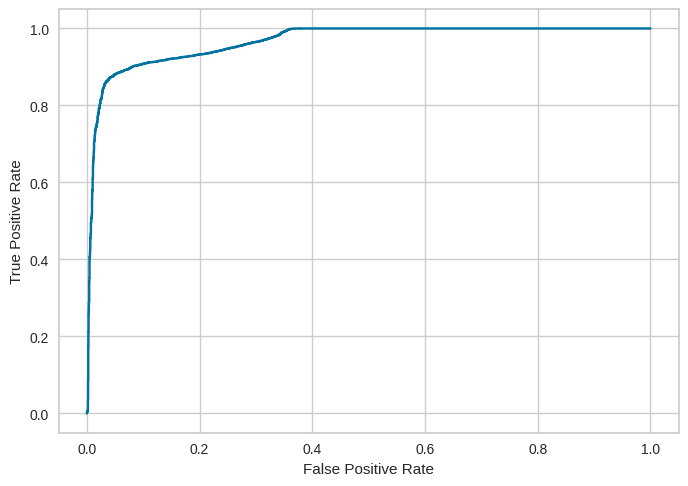


Fbeta):
  - F(2):	0.940599539496989
  - F(3):	0.9459188671683663
  - F(5):	0.9492223081550227

Confusion matrix:
array([[2651,  943],
       [ 435, 8497]])

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.74      0.79      3594
           1       0.90      0.95      0.92      8932

    accuracy                           0.89     12526
   macro avg       0.88      0.84      0.86     12526
weighted avg       0.89      0.89      0.89     12526



In [85]:
custom_classification_report(baseline_classifier, y_test)

/home/smertlove/sandbox/hse/ML_hw/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/smertlove/sandbox/hse/ML_hw/.venv/lib/python3.10/site-packages/yellowbrick/model_selection/importances.py:194: YellowbrickWarning: detected multi-dimensional feature importances but stack=False, using mean to aggregate them.
  warnings.warn(


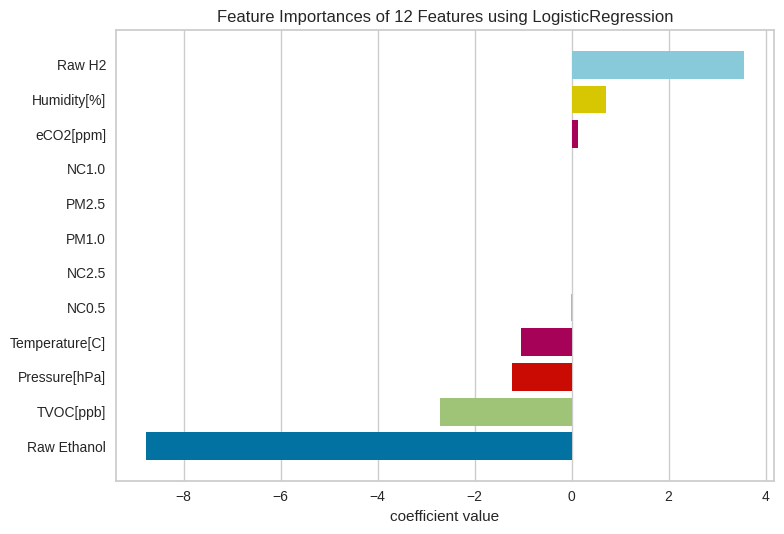

<Axes: title={'center': 'Feature Importances of 12 Features using LogisticRegression'}, xlabel='coefficient value'>

In [36]:
viz = FeatureImportances(baseline_classifier, relative=False)
viz.fit(X_train, y_train)
viz.show()

Теперь для отсампленной выборки

In [37]:
baseline_classifier = LogisticRegression(max_iter=500)

In [87]:
cv_scores = cross_val_score(
    LogisticRegression(max_iter=500),
    X_train_resamle,
    y_train_resamle,
    cv=kfold,
    scoring=MAIN_SCORE
)

/home/smertlove/sandbox/hse/ML_hw/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/smertlove/sandbox/hse/ML_hw/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

In [90]:
cv_scores

array([0.96202442, 0.95895993, 0.96366003, 0.96538656, 0.96081782])

In [38]:
baseline_classifier.fit(X_train_resamle, y_train_resamle)

/home/smertlove/sandbox/hse/ML_hw/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=500)

--- Model results ---

Recall:
0.8987908643081057

AUROC:
0.9064071182976255


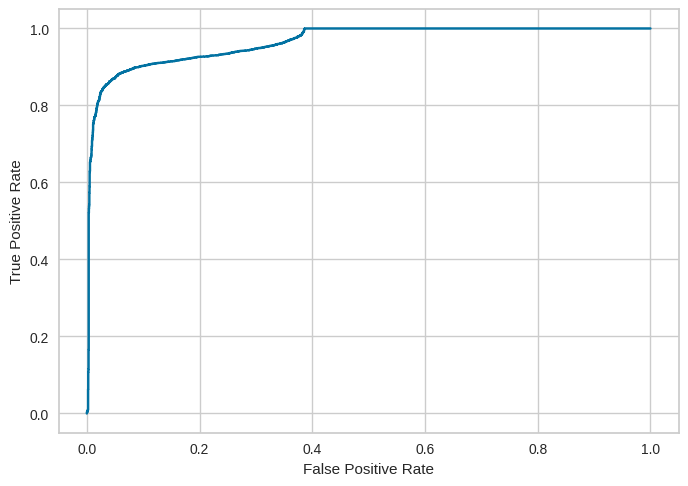


Fbeta):
  - F(2):	0.9109270396005901
  - F(3):	0.9048182586644125
  - F(5):	0.9010995652680703

Confusion matrix:
array([[3285,  309],
       [ 904, 8028]])

Classification report:
              precision    recall  f1-score   support

           0       0.78      0.91      0.84      3594
           1       0.96      0.90      0.93      8932

    accuracy                           0.90     12526
   macro avg       0.87      0.91      0.89     12526
weighted avg       0.91      0.90      0.91     12526



In [89]:
custom_classification_report(baseline_classifier, y_test)

/home/smertlove/sandbox/hse/ML_hw/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/smertlove/sandbox/hse/ML_hw/.venv/lib/python3.10/site-packages/yellowbrick/model_selection/importances.py:194: YellowbrickWarning: detected multi-dimensional feature importances but stack=False, using mean to aggregate them.
  warnings.warn(


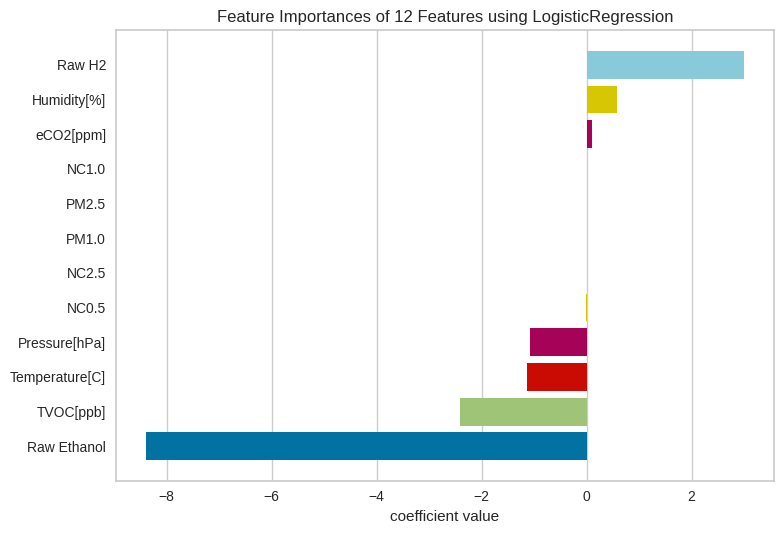

<Axes: title={'center': 'Feature Importances of 12 Features using LogisticRegression'}, xlabel='coefficient value'>

In [39]:
viz = FeatureImportances(baseline_classifier, relative=False)
viz.fit(X_train_resamle, y_train_resamle)
viz.show()

Очень долго учится. В качестве *эксперимента* натренируем один логрег 3к итераций. Учить будем на ресампленном сете. K-fold делать не будем, потому что вроде понятнор, что с выборкой все ок

In [40]:
baseline_classifier = LogisticRegression(max_iter=3000)

In [41]:
baseline_classifier.fit(X_train_resamle, y_train_resamle)

/home/smertlove/sandbox/hse/ML_hw/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=3000)

--- Model results ---

Recall:
0.8975593372145096

AUROC:
0.9085737698871658


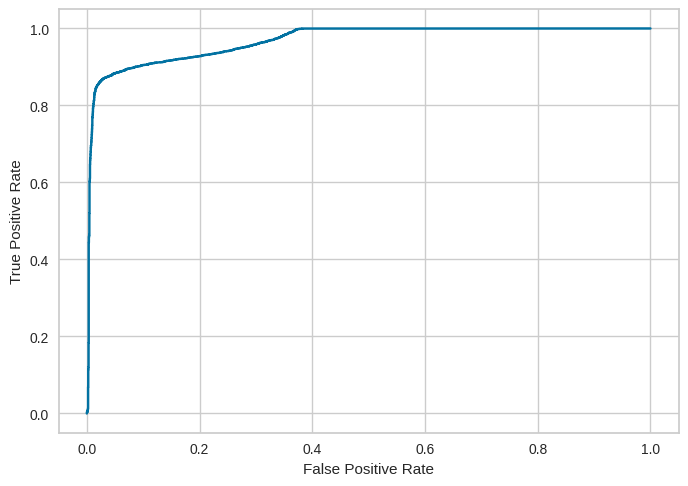


Fbeta):
  - F(2):	0.9103192987237135
  - F(3):	0.9038942882269375
  - F(5):	0.8999853198967211

Confusion matrix:
array([[3305,  289],
       [ 915, 8017]])

Classification report:
              precision    recall  f1-score   support

           0       0.78      0.92      0.85      3594
           1       0.97      0.90      0.93      8932

    accuracy                           0.90     12526
   macro avg       0.87      0.91      0.89     12526
weighted avg       0.91      0.90      0.91     12526



In [42]:
custom_classification_report(baseline_classifier, y_test)

/home/smertlove/sandbox/hse/ML_hw/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/smertlove/sandbox/hse/ML_hw/.venv/lib/python3.10/site-packages/yellowbrick/model_selection/importances.py:194: YellowbrickWarning: detected multi-dimensional feature importances but stack=False, using mean to aggregate them.
  warnings.warn(


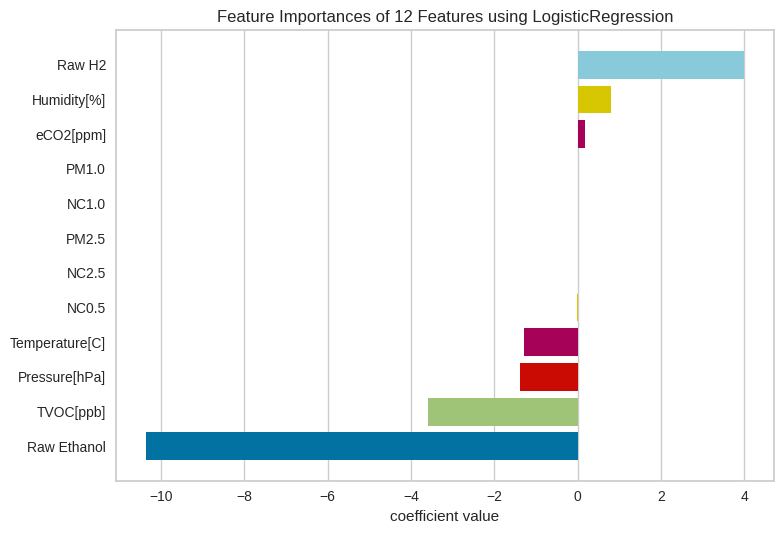

<Axes: title={'center': 'Feature Importances of 12 Features using LogisticRegression'}, xlabel='coefficient value'>

In [43]:
viz = FeatureImportances(baseline_classifier, relative=False)
viz.fit(X_train_resamle, y_train_resamle)
viz.show()

Ничего хорошего не получается, но мб подбор отсечки что-то даст

In [ ]:
def get_best_threshold(model, thresholds, X_test, y_test, metric=accuracy_score):

    probas = model.predict_proba(X_test)[:,1]

    best_threshold = 0.5  # если список thresholds, просто вернуть бейзлайн отсечку
    best_metric = -float("inf") # просто любое чило, которое точно меньше минимально возможной accuracy

    for threshold in thresholds:
        m = metric(
            y_test,
            (probas > threshold).astype(int)
        )

        if m > best_metric:
            best_metric = m
            best_threshold = threshold

    print(f"best_threshold = {best_threshold} with {metric.__name__}={best_metric}")
    return best_threshold, best_metric

In [82]:
get_best_threshold(
    baseline_classifier,
    [i / 10 for i in range(1, 10)],
    X_test,
    y_test,
    metric=roc_auc_score
)

best_threshold = 0.6 with roc_auc_score=0.9173719895900542


(0.6, np.float64(0.9173719895900542))

Стало получше, но все еще есть, куда стремиться.

### Подбор гиперпараметров

In [87]:
param_grid = {
    "penalty"     : ['l1', 'l2', 'elasticnet', None]     ,
    "C"           : [0.01],
    # "C"           : [0.001, 0.01, 0.1, 1]                ,
    "solver"      : ["lbfgs", 'liblinear', "newton-cg", 'newton-cg', "sag", "saga"],
    "multi_class" : ["ovr", "multinomial"],

    # Потому что учим на сампленном сете
    "class_weight": [None, "balanced"],

    # Потому что очень долго учится
    "max_iter"    : [50],
    "random_state": [42],
}

grid_search = GridSearchCV(
    LogisticRegression(),
    param_grid=param_grid,
    cv=kfold
)

In [88]:
import warnings
warnings.filterwarnings("ignore")

In [96]:
grid_search.fit(X_train_resamle, y_train_resamle)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(),
             param_grid={'C': [0.01], 'class_weight': [None, 'balanced'],
                         'max_iter': [50],
                         'multi_class': ['ovr', 'multinomial'],
                         'penalty': ['l1', 'l2', 'elasticnet', None],
                         'random_state': [42],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cg', 'sag', 'saga']})

In [97]:
grid_search.best_params_, grid_search.best_score_

({'C': 0.01,
  'class_weight': 'balanced',
  'max_iter': 50,
  'multi_class': 'ovr',
  'penalty': 'l1',
  'random_state': 42,
  'solver': 'liblinear'},
 np.float64(0.9053733426378228))

In [98]:
best_logreg = LogisticRegression(**grid_search.best_params_)

In [99]:
best_logreg.fit(X_train_resamle, y_train_resamle)

LogisticRegression(C=0.01, class_weight='balanced', max_iter=50,
                   multi_class='ovr', penalty='l1', random_state=42,
                   solver='liblinear')

--- Model results ---

Recall:
0.896551724137931

AUROC:
0.9066787557807073


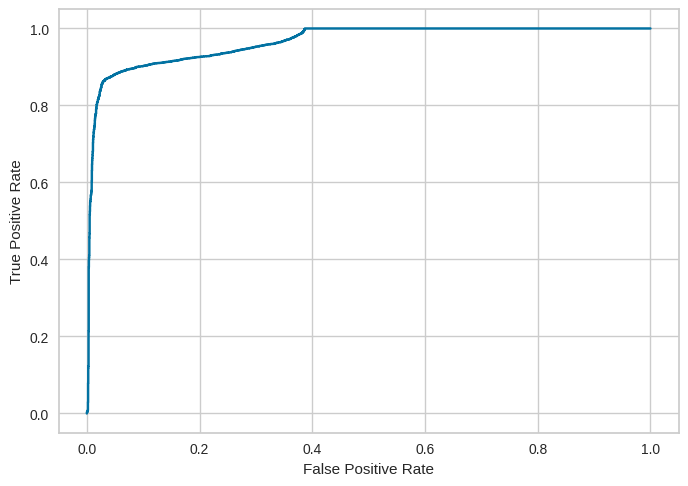


Fbeta):
  - F(2):	0.9092767117065971
  - F(3):	0.9028693838435087
  - F(5):	0.8989711019097005

Confusion matrix:
array([[3295,  299],
       [ 924, 8008]])

Classification report:
              precision    recall  f1-score   support

           0       0.78      0.92      0.84      3594
           1       0.96      0.90      0.93      8932

    accuracy                           0.90     12526
   macro avg       0.87      0.91      0.89     12526
weighted avg       0.91      0.90      0.90     12526



In [100]:
custom_classification_report(best_logreg, y_test)

In [101]:
get_best_threshold(
    best_logreg,
    [i / 10 for i in range(1, 10)],
    X_test,
    y_test,
    metric=roc_auc_score
)

best_threshold = 0.6 with roc_auc_score=0.9161272544353543


(0.6, np.float64(0.9161272544353543))

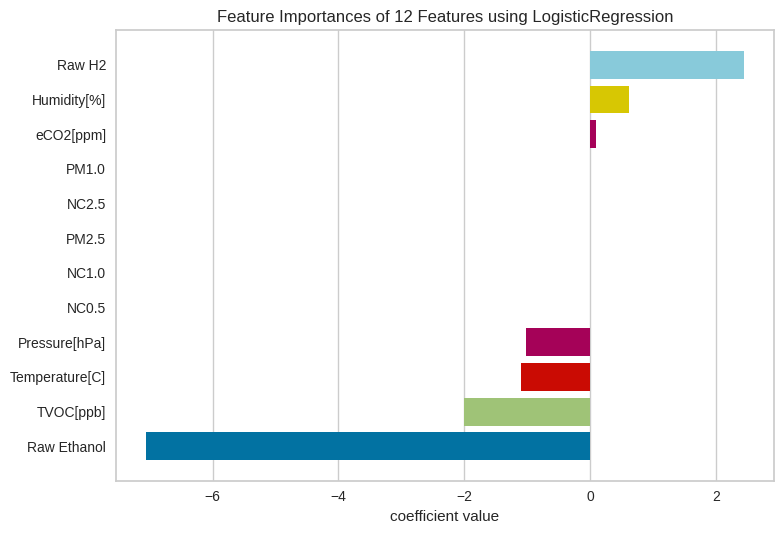

<Axes: title={'center': 'Feature Importances of 12 Features using LogisticRegression'}, xlabel='coefficient value'>

In [102]:
viz = FeatureImportances(best_logreg, relative=False)
viz.fit(X_train_resamle, y_train_resamle)
viz.show()

Возможно, стоило провести feature-engeneering поумнее, но в целом кажется, что дальше пушить логрег тут не стоит, и нужно попробовать что-то чуть более серьезное. Это что-то чуть более серьезное очень удачно находится в следующем пункте задания.

### Baseline LGBM

Сначала надо решить это

`[LightGBM] [Fatal] Do not support special JSON characters in feature name.`

In [ ]:
X_train.columns

Index(['Temperature[C]', 'Humidity[%]', 'TVOC[ppb]', 'eCO2[ppm]', 'Raw H2',
       'Raw Ethanol', 'Pressure[hPa]', 'PM1.0', 'PM2.5', 'NC0.5', 'NC1.0',
       'NC2.5'],
      dtype='object')

In [106]:
import re
X_train = X_train.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))

In [107]:
X_train.columns

Index(['TemperatureC', 'Humidity', 'TVOCppb', 'eCO2ppm', 'RawH2', 'RawEthanol',
       'PressurehPa', 'PM10', 'PM25', 'NC05', 'NC10', 'NC25'],
      dtype='object')

In [109]:
# Скоринг без ресамплинга
cross_val_score(
    LGBMClassifier(verbose=-1),
    X_train,
    y_train,
    cv=kfold,
    scoring=MAIN_SCORE
)

array([1.        , 0.9999999 , 1.        , 0.99988142, 1.        ])

In [110]:
baseline_lgbm = LGBMClassifier(verbose=-1)

In [111]:
baseline_lgbm.fit(X_train, y_train)

LGBMClassifier(verbose=-1)

--- Model results ---

Recall:
1.0

AUROC:
1.0


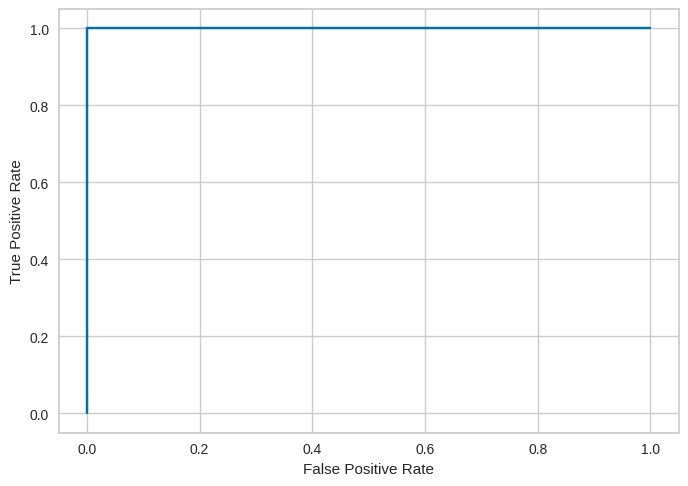


Fbeta):
  - F(2):	1.0
  - F(3):	1.0
  - F(5):	1.0

Confusion matrix:
array([[3594,    0],
       [   0, 8932]])

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3594
           1       1.00      1.00      1.00      8932

    accuracy                           1.00     12526
   macro avg       1.00      1.00      1.00     12526
weighted avg       1.00      1.00      1.00     12526



In [112]:
custom_classification_report(baseline_lgbm, y_test)

Без комментариев

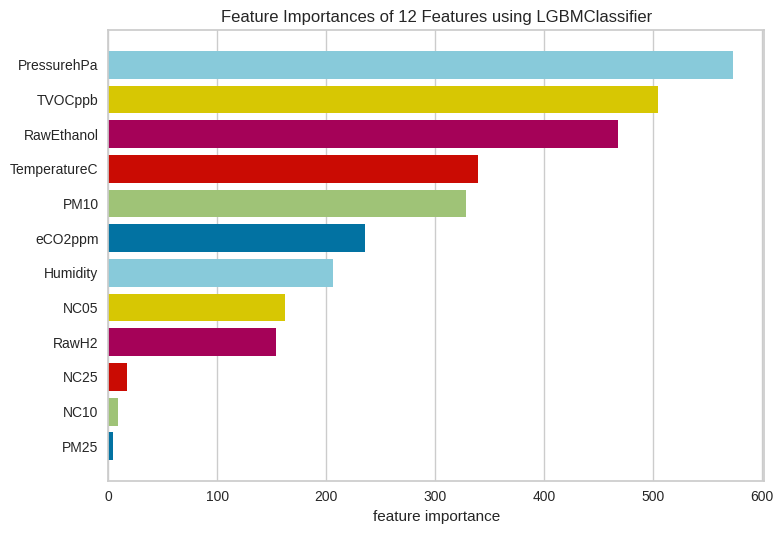

<Axes: title={'center': 'Feature Importances of 12 Features using LGBMClassifier'}, xlabel='feature importance'>

In [113]:
viz = FeatureImportances(baseline_lgbm, relative=False)
viz.fit(X_train, y_train)
viz.show()

### Подбор параметров LGBM

In [119]:
param_grid = {
    "boosting_type": ['gbdt',],
    "num_leaves": [3, 15, 25, 31],
    "max_depth": [-1, 5, 10, 20, 40],
    "n_estimators": [60, 120, 240],
    "min_child_weight": [1e-3, 1e-2, 1e-1],
    "random_state": [42],
    "n_jobs": [-1],
    "verbose": [-1]
}

In [120]:
# Не попробую.
grid_search = GridSearchCV(
    LGBMClassifier(),
    param_grid=param_grid,
    cv=kfold,
    verbose= False
)

In [122]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LGBMClassifier(),
             param_grid={'boosting_type': ['gbdt'],
                         'max_depth': [-1, 5, 10, 20, 40],
                         'min_child_weight': [0.001, 0.01, 0.1],
                         'n_estimators': [60, 120, 240], 'n_jobs': [-1],
                         'num_leaves': [3, 15, 25, 31], 'random_state': [42],
                         'verbose': [-1]},
             verbose=False)

In [123]:
grid_search.best_params_, grid_search.best_score_

({'boosting_type': 'gbdt',
  'max_depth': -1,
  'min_child_weight': 0.001,
  'n_estimators': 120,
  'n_jobs': -1,
  'num_leaves': 15,
  'random_state': 42,
  'verbose': -1},
 np.float64(0.9999401257359544))

In [127]:
cross_val_score(
    LGBMClassifier(**grid_search.best_params_),
    X_train,
    y_train,
    cv=kfold,
    scoring=MAIN_SCORE
)

array([1.        , 0.99999995, 1.        , 0.99999975, 1.        ])

In [124]:
best_lgbm = LGBMClassifier(**grid_search.best_params_)

In [125]:
best_lgbm.fit(X_train, y_train)

LGBMClassifier(n_estimators=120, n_jobs=-1, num_leaves=15, random_state=42,
               verbose=-1)

--- Model results ---

Recall:
1.0

AUROC:
1.0


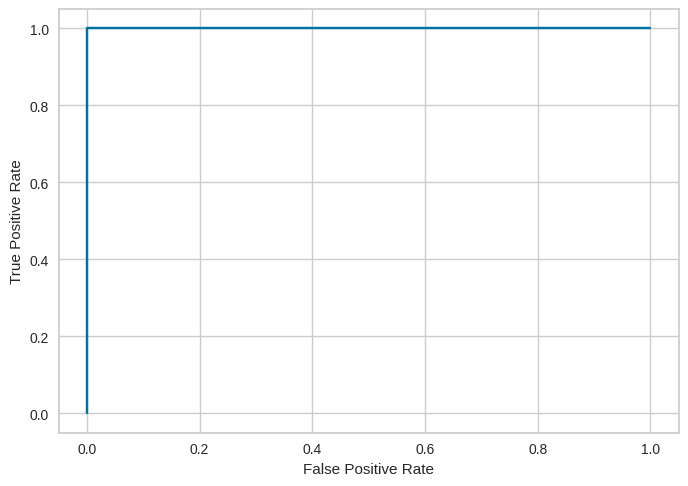


Fbeta):
  - F(2):	1.0
  - F(3):	1.0
  - F(5):	1.0

Confusion matrix:
array([[3594,    0],
       [   0, 8932]])

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3594
           1       1.00      1.00      1.00      8932

    accuracy                           1.00     12526
   macro avg       1.00      1.00      1.00     12526
weighted avg       1.00      1.00      1.00     12526



In [126]:
custom_classification_report(best_lgbm, y_test)

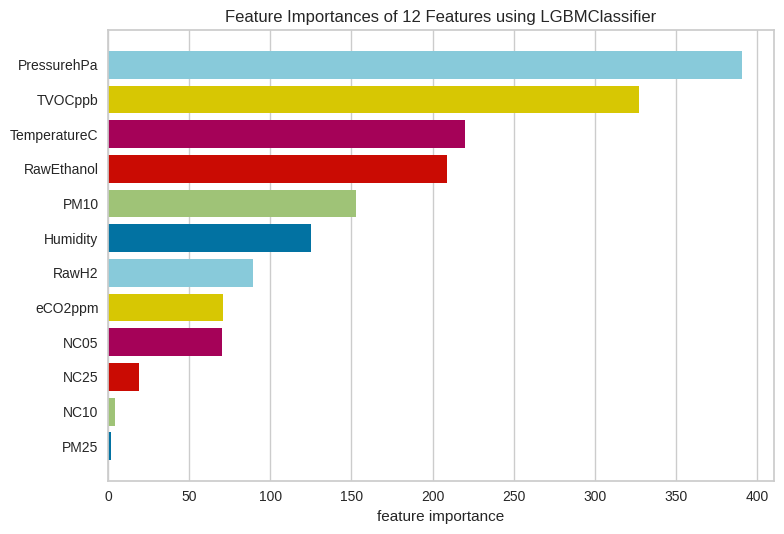

<Axes: title={'center': 'Feature Importances of 12 Features using LGBMClassifier'}, xlabel='feature importance'>

In [128]:
viz = FeatureImportances(best_lgbm, relative=False)
viz.fit(X_train, y_train)
viz.show()